# 🔧 A Comparative Modeling of Behavioral and Technological Interventions
![🧠 Project Mindmap](data/energy_optimization_mindmap.jpg)

## 📝 Synopsis
This project analyzes hourly heat and electricity demand data from German households to evaluate cost, carbon emissions, and system performance under different scenarios. It applies optimization and data analysis techniques to model the impact of transitioning from traditional energy sources to smart, sustainable alternatives like solar power and smart home systems. The analysis includes demand profiling, cost and emission evaluations, and return on investment (ROI) assessments.

##  Scenarios Covered

###  **Baseline Scenario**
- Calculate average hourly heat and electricity demand.
- Compute yearly energy costs and CO₂ emissions.

###  **Scenario 1: Solar PV Integration**
- Optimize energy cost by shifting electricity usage from grid to solar (PV).
- Calculate yearly CO₂ emissions and ROI.

###  **Scenario 2: Smart Home Integration**
- Introduce smart home technology for energy management.
- Repeat cost, emission, and ROI analysis as in Scenario 1.

###  **Scenario 3: Social Comparison and Nudges**
- Incorporate behavioral nudges and social comparison.
- Repeat calculations similar to Scenario 1.

###  **Scenario 4: Real-Time Feedback via Smart Meters**
- Analyze impact of real-time consumption feedback.
- Repeat optimization and environmental-economic analysis.

---

> 💡 *Note:* This code is modular and can be extended to include more advanced energy optimization models or behavioral simulations in future iterations.


This section imports all required libraries for energy system modeling, data analysis, and visualization

In [3]:
import linopy 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as patches
from xarray import DataArray
import warnings
warnings.filterwarnings("ignore")

print("Section 1: Libraries imported successfully.")

Section 1: Libraries imported successfully.


Defines utility functions for calculating energy costs

In [4]:
def calculate_energy_cost(energy_demand):
    '''
        Energy cost = Demand * 0.32 Euro/kWh
    '''
    return energy_demand * 0.32

def calculate_cost(energy_demand, investment_cost, carbon_cost=0.08):
    energy_cost = t(energy_demand)
    cost = energy_cost + investment_cost + carbon_cost

This section loads, cleans, and averages hourly electricity and heat demand data for German households, creating a structured DataFrame for further energy system analysis and optimization.

In [5]:

elec_df = pd.read_csv("Data/electricity_demands_kWh.csv")
heat_df = pd.read_csv("Data/heat_demands_kWh.csv")


elec_df = elec_df.loc[:, ~elec_df.columns.str.contains('^Unnamed')]
heat_df = heat_df.loc[:, ~heat_df.columns.str.contains('^Unnamed')]

numbers = list(range(8760))

time_index = pd.Index(numbers, dtype='int64', name='time')

print(time_index.size)


elec_df = elec_df.apply(pd.to_numeric, errors='coerce')
heat_df = heat_df.apply(pd.to_numeric, errors='coerce')


avg_elec_demand = elec_df.mean(axis=1)
avg_heat_demand = heat_df.mean(axis=1)

df_demand = pd.DataFrame({
    'elec_demand_kWh': avg_elec_demand.values,
    'heat_demand_kWh': avg_heat_demand.values
}, index=time_index)


(df_demand)

8760


,elec_demand_kWh,heat_demand_kWh
time,,
0,0.123006,2.162897
1,0.121895,2.229832
2,0.135482,2.310730
3,0.124523,2.517697
4,0.135651,3.113016
...,...,...
8755,0.686075,5.316105
8756,0.802304,4.676496
8757,0.740687,3.699696


This Section Sums the total annual electricity and heat demand, then renames the columns to indicate yearly values, providing a clear summary for further analysis.

In [6]:

df_demand = df_demand.sum().to_frame().T
df_demand.columns = [f'{col[:-1] + 'y'}' for col in df_demand.columns]

print(df_demand)

   elec_demand_kWy  heat_demand_kWy
0      3074.919439     18520.115844


This Section creates a DataFrame of hourly electricity and heat demand, then calculates the average demand for each hour of a typical day across the year, summarizing daily patterns for further analysis.

In [7]:

df_hourly = pd.DataFrame({
    'elec_demand_kWh': avg_elec_demand.values,
    'heat_demand_kWh': avg_heat_demand.values
}, index=time_index)


elec_daily_avg = df_hourly['elec_demand_kWh'].values.reshape((365, 24)).mean(axis=0)
heat_daily_avg = df_hourly['heat_demand_kWh'].values.reshape((365, 24)).mean(axis=0)


avg_day_df = pd.DataFrame({
    'hour': range(24),
    'avg_elec_demand_kWh': elec_daily_avg,
    'avg_heat_demand_kWh': heat_daily_avg
})

print(avg_day_df)


    hour  avg_elec_demand_kWh  avg_heat_demand_kWh
0      0             0.224018             0.861920
1      1             0.173219             0.862634
2      2             0.160659             0.906000
3      3             0.136393             1.049641
4      4             0.136012             1.446664
5      5             0.179783             2.342592
6      6             0.275809             3.155414
7      7             0.291141             3.049718
8      8             0.290032             2.789446
9      9             0.308530             2.612049
10    10             0.320833             2.387112
11    11             0.382075             2.176851
12    12             0.388355             2.138345
13    13             0.377019             2.094782
14    14             0.356844             2.165523
15    15             0.373730             2.207279
16    16             0.403341             2.366540
17    17             0.503025             2.523532
18    18             0.586450  

This section formulates and solves an optimization model to determine the optimal mix of grid and solar electricity supply for each hour of a typical day. It uses hourly demand and solar capacity factors, sets constraints, and minimizes a combined cost and emission objective. The results show the required solar capacity, total solar generation, and grid electricity needed.

In [8]:

elec_demand_day = avg_day_df['avg_elec_demand_kWh'].values
time = pd.Index(range(24), name="hour")


solar_cf = np.array([
    0.00, 0.00, 0.00, 0.02, 0.05, 0.15, 0.40, 0.65,
    0.85, 0.90, 0.95, 1.00, 0.95, 0.85, 0.60, 0.35,
    0.15, 0.05, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00
])

model = linopy.Model()

grid_supply = model.add_variables(coords=[time], name="grid_supply", lower=0)
solar_supply = model.add_variables(coords=[time], name="solar_supply", lower=0)
solar_capacity = model.add_variables(name="solar_capacity", lower=0)


model.add_constraints(grid_supply + solar_supply >= elec_demand_day, name="demand")


from xarray import DataArray


solar_capacity_vector = solar_capacity.to_linexpr().expand_dims(hour=time)
solar_cf_da = DataArray(solar_cf, coords=[time], dims=["hour"])

model.add_constraints(solar_supply <= solar_capacity_vector * solar_cf_da, name="cf_limit")



grid_cost = grid_supply * 0.32
grid_emission = grid_supply * 0.35 * 0.08
solar_invest = solar_capacity * 0.1

objective = (
    0.5 * grid_emission.sum() +
    0.5 * (grid_cost.sum() + solar_invest)
)

model.add_objective(objective, sense="min")


res = model.solve(solver_name="gurobi")
sol = model.solution

print("\n=== Results: Hourly CF Model ===")
print(f"Installed solar capacity: {sol['solar_capacity'].values:.2f} kW")
print(f"Total solar supply: {sol['solar_supply'].sum():.2f} kWh")
print(f"Total grid supply: {sol['grid_supply'].sum():.2f} kWh")


Restricted license - for non-production use only - expires 2026-11-23
Read LP format model from file C:\Users\linus\AppData\Local\Temp\linopy-problem-8kiwe954.lp
Reading time = 0.00 seconds
obj: 48 rows, 49 columns, 88 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26120.2))

CPU model: AMD Ryzen 7 4800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 48 rows, 49 columns and 88 nonzeros
Model fingerprint: 0x17b9ac65
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [5e-02, 2e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 6e-01]
Presolve removed 42 rows and 42 columns
Presolve time: 0.00s
Presolved: 6 rows, 7 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.5221641e-01   1.124806e+00   0.000000e+00      0s
       4    8.4793273e-01   0.000000e+00   0.0

Section Below will calculate the annual emissions, cost and ROI of this optimized mix of solar, grid and heat staying on the conventional system.

This code calculates the annual CO₂ emissions for electricity and heat after solar PV installation. It sums the optimized grid electricity and heat demand, applies emission factors, and prints the total emissions for both sources and their combined value.

In [9]:

grid_kWh_total = sol['grid_supply'].sum().values  # in kWh
heat_kWh_total = df_hourly['heat_demand_kWh'].sum()  # in kWh


emission_factor = 0.35  # kgCO2 per kWh


electric_emissions = grid_kWh_total * emission_factor *365
heat_emissions = heat_kWh_total * emission_factor

total_emissions = electric_emissions + heat_emissions

print(f"Annual Electricity-related emissions: {electric_emissions:.2f} kgCO₂")
print(f"Annual Heating-related emissions: {heat_emissions:.2f} kgCO₂")
print(f"Total emissions after PV installation: {total_emissions:.2f} kgCO₂")


Annual Electricity-related emissions: 523.84 kgCO₂
Annual Heating-related emissions: 6482.04 kgCO₂
Total emissions after PV installation: 7005.88 kgCO₂


This Section calculates the financial and environmental benefits of installing solar PV. It compares baseline and post-solar electricity costs and emission costs, computes total annual savings, investment required, and the return on investment (ROI), then prints a summary of these results.

In [10]:

solar_capacity_kWp = sol['solar_capacity'].values
grid_kWh_total = sol['grid_supply'].sum().values
solar_kWh_total = sol['solar_supply'].sum().values

# Constants
carbon_price = 0.08  # €/kgCO2
emission_factor = 0.35  # kgCO2/kWh
grid_price = 0.32  # €/kWh
install_cost_per_kwp = 1100  # €/kWp

# Full demand
total_demand_kWh = df_hourly['elec_demand_kWh'].sum()

# Without solar (baseline)
baseline_grid_cost = total_demand_kWh * grid_price
baseline_emission_cost = total_demand_kWh * emission_factor * carbon_price

# With solar
actual_grid_cost = grid_kWh_total * grid_price
actual_emission_cost = grid_kWh_total * emission_factor * carbon_price

# Savings
energy_cost_saving = baseline_grid_cost - actual_grid_cost
emission_cost_saving = baseline_emission_cost - actual_emission_cost
total_annual_saving = energy_cost_saving + emission_cost_saving

# Investment
total_investment = solar_capacity_kWp * install_cost_per_kwp

# ROI
roi = (total_annual_saving / total_investment) * 100

print(f" Installed PV capacity: {solar_capacity_kWp:.2f} kWp")
print(f" Investment cost: €{total_investment:.2f}")
print(f" Emission cost saved: €{emission_cost_saving:.2f}")
print(f" Grid electricity cost saved: €{energy_cost_saving:.2f}")
print(f" Total annual savings: €{total_annual_saving:.2f}")
print(f" ROI: {roi:.2f}% per year")


 Installed PV capacity: 2.69 kWp
 Investment cost: €2957.83
 Emission cost saved: €85.98
 Grid electricity cost saved: €982.66
 Total annual savings: €1068.64
 ROI: 36.13% per year


PV Upgrade Impact Dashboard

This section visualizes the financial and environmental benefits of solar PV installation. It compares electricity costs, CO₂ emissions, and annual savings before and after PV adoption using bar and donut charts, and summarizes ROI, savings, installed capacity, and investment in a dashboard format.

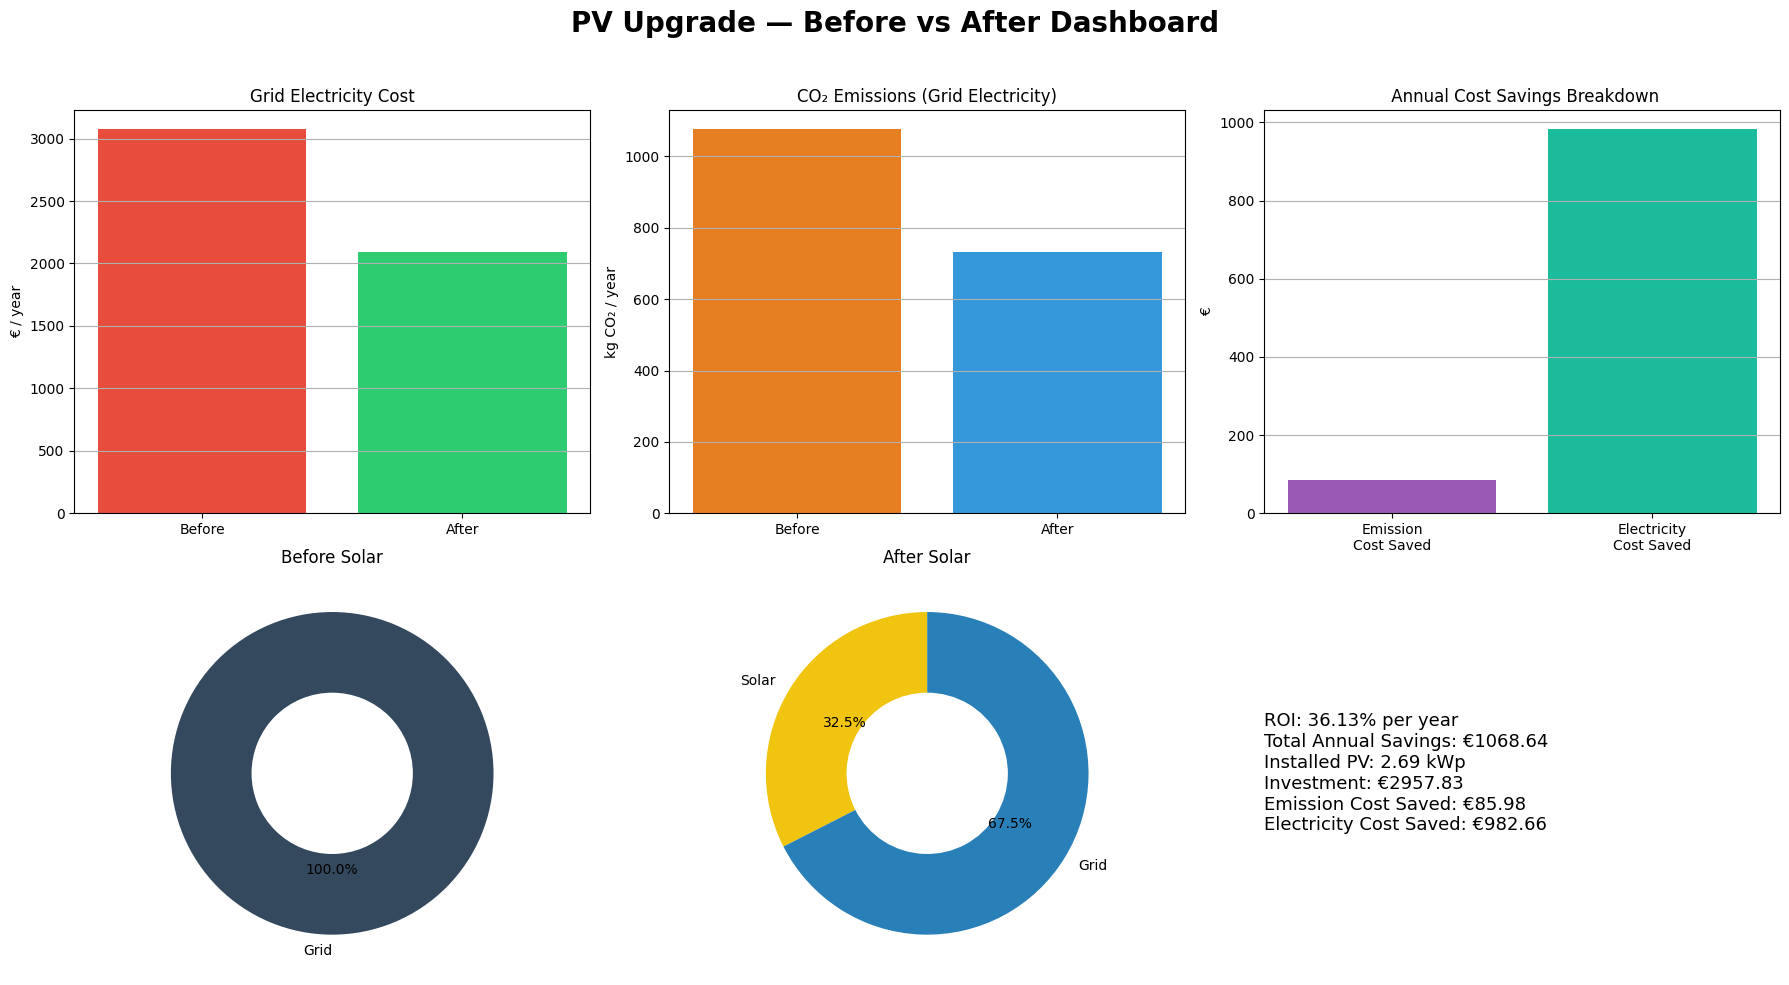

In [11]:

# --- Given Values ---
cost_before = 3074.92
cost_after = 2092.26

emissions_before = 3074.92 * 0.35  # Assuming 0.35 kgCO2/kWh × cost_proxy
emissions_after = 2092.26 * 0.35

investment_cost = 2957.83
solar_capacity_kWp = 2.69
emission_cost_saving = 85.98
grid_saving_cost = 982.66
total_savings = 1068.64
roi = 36.13

# Dummy energy shares
grid_kWh_before = 10000
solar_kWh_after = 3250
grid_kWh_after = 6750

# --- Plotting ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("PV Upgrade — Before vs After Dashboard", fontsize=20, fontweight='bold')

# 1. Electricity Cost (Before vs After)
axs[0, 0].bar(['Before', 'After'], [cost_before, cost_after], color=['#e74c3c', '#2ecc71'])
axs[0, 0].set_title('Grid Electricity Cost')
axs[0, 0].set_ylabel('€ / year')
axs[0, 0].grid(True, axis='y')

# 2. Emissions (Before vs After)
axs[0, 1].bar(['Before', 'After'], [emissions_before, emissions_after], color=['#e67e22', '#3498db'])
axs[0, 1].set_title('CO₂ Emissions (Grid Electricity)')
axs[0, 1].set_ylabel('kg CO₂ / year')
axs[0, 1].grid(True, axis='y')

# 3. Savings Breakdown
axs[0, 2].bar(['Emission\nCost Saved', 'Electricity\nCost Saved'], [emission_cost_saving, grid_saving_cost],
              color=['#9b59b6', '#1abc9c'])
axs[0, 2].set_title(' Annual Cost Savings Breakdown')
axs[0, 2].set_ylabel('€')
axs[0, 2].grid(True, axis='y')

# 4. Donut: Before (100% Grid)
axs[1, 0].pie([grid_kWh_before], labels=['Grid'], colors=['#34495e'], startangle=90,
              wedgeprops=dict(width=0.5), autopct='%1.1f%%')
axs[1, 0].set_title("Before Solar")

# 5. Donut: After (Solar + Grid)
axs[1, 1].pie([solar_kWh_after, grid_kWh_after], labels=['Solar', 'Grid'],
              colors=['#f1c40f', '#2980b9'], startangle=90, autopct='%1.1f%%',
              wedgeprops=dict(width=0.5))
axs[1, 1].set_title("After Solar")

# 6. Summary Box
axs[1, 2].axis('off')
summary = (
    f"ROI: {roi:.2f}% per year\n"
    f"Total Annual Savings: €{total_savings:.2f}\n"
    f"Installed PV: {solar_capacity_kWp:.2f} kWp\n"
    f"Investment: €{investment_cost:.2f}\n"
    f"Emission Cost Saved: €{emission_cost_saving:.2f}\n"
    f"Electricity Cost Saved: €{grid_saving_cost:.2f}"
)
axs[1, 2].text(0, 0.5, summary, fontsize=13, va='center', ha='left')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


Scenario 2 Heat Pump 

This code models the impact of integrating smart home technology with solar PV. It reduces electricity and heat demand, optimizes the mix of grid and solar supply, and calculates annual costs, emissions, savings, investment, and ROI. The results show how smart interventions and PV installation improve financial and environmental performance compared to the baseline.

In [12]:
# Constants
elec_reduction = 0.08
heat_reduction = 0.14
cost_smart_plugs = 100
cost_smart_thermostat = 250
grid_price = 0.32
carbon_price = 0.08
emission_factor = 0.35
install_cost_per_kwp = 1100


solar_cf = np.array([
    0.00, 0.00, 0.00, 0.02, 0.05, 0.15, 0.40, 0.65,
    0.85, 0.90, 0.95, 1.00, 0.95, 0.85, 0.60, 0.35,
    0.15, 0.05, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00
])


time = pd.Index(range(24), name="hour")

# Baseline daily profile
elec_demand_day = avg_day_df['avg_elec_demand_kWh'].values
heat_demand_day = avg_day_df['avg_heat_demand_kWh'].values

# Modified demand with smart home
elec_demand_day_mod = elec_demand_day * (1 - elec_reduction)
heat_demand_day_mod = heat_demand_day * (1 - heat_reduction)


model = linopy.Model()
g = model.add_variables(coords=[time], name="grid_supply", lower=0)
s = model.add_variables(coords=[time], name="solar_supply", lower=0)
C = model.add_variables(name="solar_capacity", lower=0)

solar_cf_da = DataArray(solar_cf, coords=[time], dims=["hour"])

# Constraints
model.add_constraints(g + s >= elec_demand_day_mod, name="demand")
model.add_constraints(s <= C.to_linexpr().expand_dims(hour=time) * solar_cf_da, name="cf_limit")

# Objective
grid_cost = g * grid_price
grid_emiss_cost = g * emission_factor * carbon_price
solar_inv = C * 0.1

objective = 0.5 * (grid_emiss_cost.sum()) + 0.5 * (grid_cost.sum() + solar_inv)
model.add_objective(objective, sense="min")

# Solve
res = model.solve(solver_name="gurobi")
sol = model.solution

# Results
solar_capacity_kWp = sol['solar_capacity'].values
grid_kWh_total = sol['grid_supply'].sum().values * 365
solar_kWh_total = sol['solar_supply'].sum().values * 365

# BASELINE vs SMART+PV ANALYSIS
baseline_elec_demand = elec_demand_day.sum() * 365
baseline_heat_demand = heat_demand_day.sum() * 365

post_heat_demand = heat_demand_day_mod.sum() * 365

baseline_emissions = (baseline_elec_demand + baseline_heat_demand) * emission_factor
post_emissions = (grid_kWh_total + post_heat_demand) * emission_factor

baseline_energy_cost = baseline_elec_demand * grid_price
baseline_emission_cost = baseline_emissions * carbon_price

post_energy_cost = grid_kWh_total * grid_price
post_emission_cost = post_emissions * carbon_price

# Savings
emissions_saved = baseline_emissions - post_emissions
cost_saved = (baseline_energy_cost + baseline_emission_cost) - (post_energy_cost + post_emission_cost)

# Investment
total_investment = solar_capacity_kWp * install_cost_per_kwp + cost_smart_plugs + cost_smart_thermostat
roi_cumulative = (cost_saved / total_investment) * 100


# RESULTS OUTPUT
print("\n===  Results: Smart Home + PV (24h profile scaled) ===")
print(f" Installed PV capacity: {solar_capacity_kWp:.2f} kWp")
print(f" Annual Grid supply: {grid_kWh_total:.2f} kWh")
print(f" Annual Solar supply: {solar_kWh_total:.2f} kWh")
print(f" Emissions avoided: {emissions_saved:.2f} kg CO₂")
print(f"Total cost saved: €{cost_saved:.2f}")
print(f"Total investment: €{total_investment:.2f}")
print(f"Cumulative ROI: {roi_cumulative:.2f}% per year")


Restricted license - for non-production use only - expires 2026-11-23
Read LP format model from file C:\Users\linus\AppData\Local\Temp\linopy-problem-lz9_49ko.lp
Reading time = 0.00 seconds
obj: 48 rows, 49 columns, 88 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26120.2))

CPU model: AMD Ryzen 7 4800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 48 rows, 49 columns and 88 nonzeros
Model fingerprint: 0x5a445b2c
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [5e-02, 2e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 6e-01]
Presolve removed 42 rows and 42 columns
Presolve time: 0.01s
Presolved: 6 rows, 7 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.0003910e-01   1.034822e+00   0.000000e+00      0s
       4    7.8009811e-01   0.000000e+00   0.0

This Section visualizes the impact of smart home technology combined with solar PV on household energy use. It compares grid electricity cost, CO₂ emissions, and annual savings before and after upgrades, using bar and donut charts. The dashboard summarizes ROI, total savings, installed PV capacity, investment, and cost savings, highlighting financial and environmental improvements.

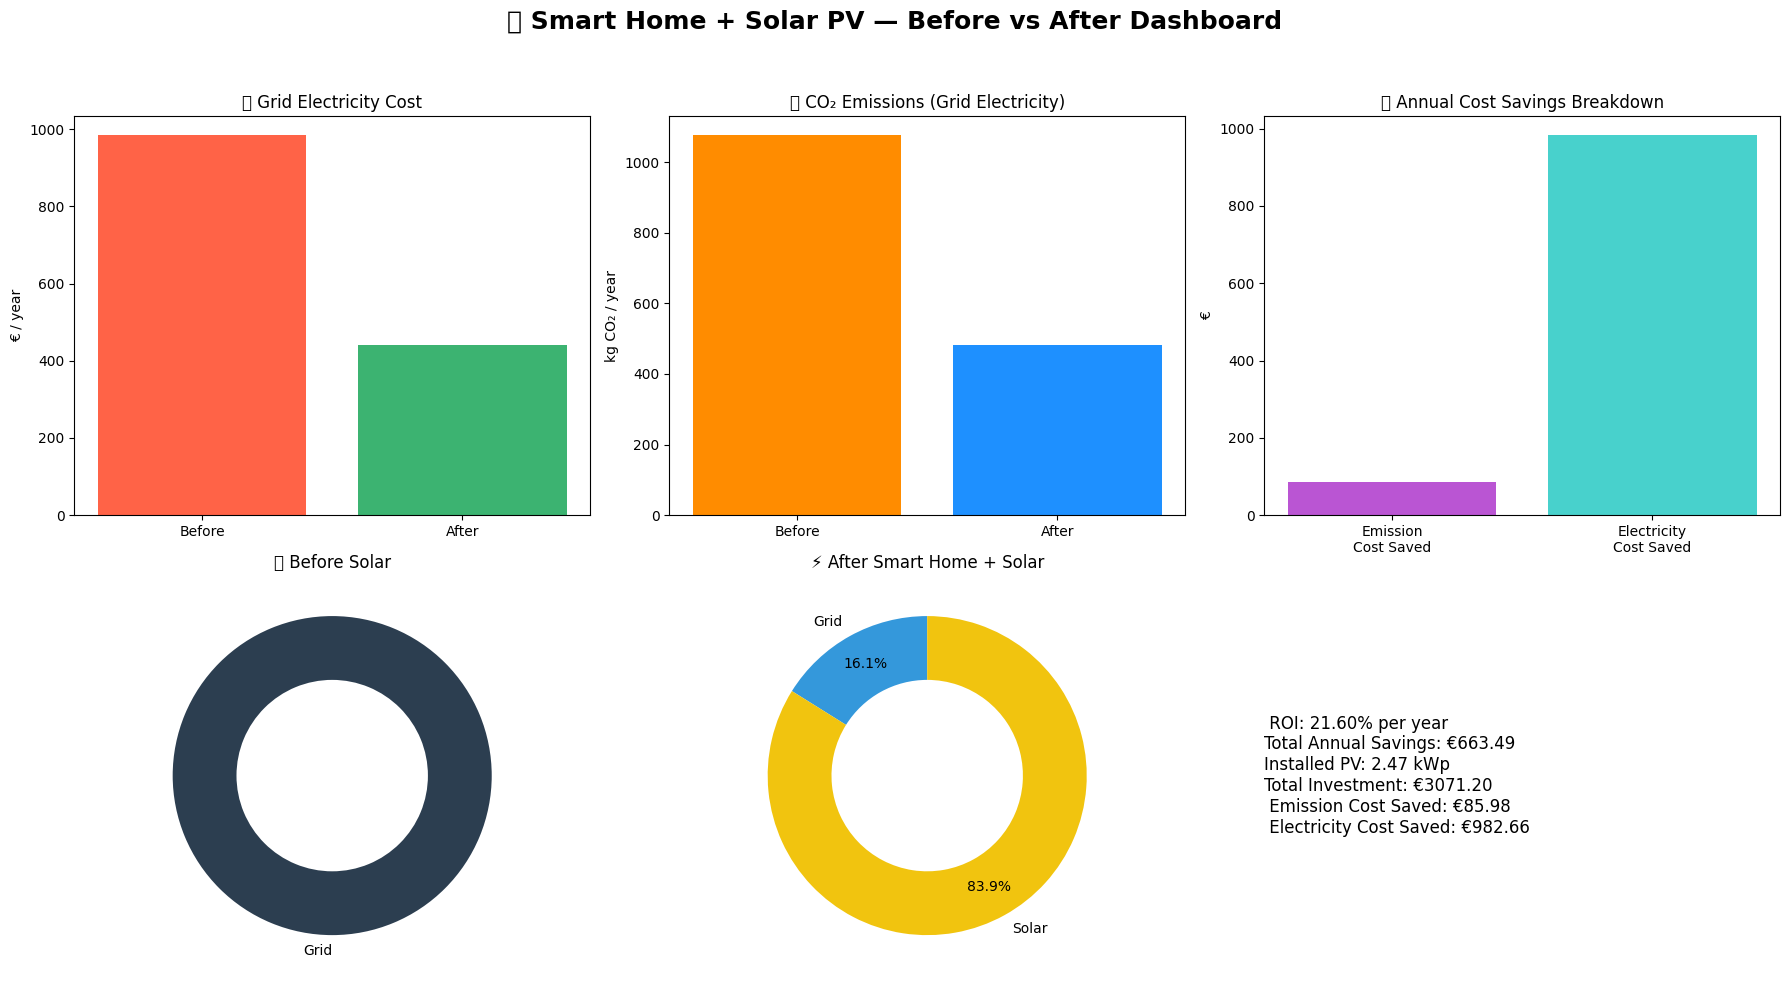

In [13]:

total_energy_after = grid_kWh_total + solar_kWh_total + 1e-6  # avoid zero-div
grid_share = grid_kWh_total / total_energy_after
solar_share = solar_kWh_total / total_energy_after

# --- Create Figure ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🏠 Smart Home + Solar PV — Before vs After Dashboard", fontsize=18, fontweight='bold')

# 1️⃣ Grid Electricity Cost
axs[0, 0].bar(['Before', 'After'], [baseline_energy_cost, post_energy_cost], 
              color=['tomato', 'mediumseagreen'])
axs[0, 0].set_title("💶 Grid Electricity Cost")
axs[0, 0].set_ylabel("€ / year")

# 2️⃣ CO₂ Emissions (Electricity Only)
axs[0, 1].bar(['Before', 'After'],
              [baseline_elec_demand * emission_factor, grid_kWh_total * emission_factor],
              color=['darkorange', 'dodgerblue'])
axs[0, 1].set_title("💨 CO₂ Emissions (Grid Electricity)")
axs[0, 1].set_ylabel("kg CO₂ / year")

# 3️⃣ Cost Saving Breakdown
axs[0, 2].bar(['Emission\nCost Saved', 'Electricity\nCost Saved'], 
              [emission_cost_saving, energy_cost_saving],
              color=['mediumorchid', 'mediumturquoise'])
axs[0, 2].set_title("💡 Annual Cost Savings Breakdown")
axs[0, 2].set_ylabel("€")

# 4️⃣ Donut Chart - Before (100% Grid)
axs[1, 0].pie([1], labels=['Grid'], colors=['#2c3e50'], startangle=90, wedgeprops=dict(width=0.4))
axs[1, 0].text(0, 0, '100.0%', ha='center', va='center', fontsize=12, color='white')
axs[1, 0].set_title("🔌 Before Solar")

# 5️⃣ Donut Chart - After (Solar + Grid)
axs[1, 1].pie([grid_share, solar_share],
              labels=['Grid', 'Solar'],
              colors=['#3498db', '#f1c40f'],
              startangle=90,
              autopct='%1.1f%%',
              pctdistance=0.8,
              wedgeprops=dict(width=0.4))
axs[1, 1].set_title("⚡ After Smart Home + Solar")

# 6️⃣ Text Dashboard Summary
axs[1, 2].axis('off')
summary_text = (
    f" ROI: {roi_cumulative:.2f}% per year\n"
    f"Total Annual Savings: €{cost_saved:.2f}\n"
    f"Installed PV: {solar_capacity_kWp:.2f} kWp\n"
    f"Total Investment: €{total_investment:.2f}\n"
    f" Emission Cost Saved: €{emission_cost_saving:.2f}\n"
    f" Electricity Cost Saved: €{energy_cost_saving:.2f}"
)
axs[1, 2].text(0, 0.5, summary_text, fontsize=12, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Smart Meter + Solar PV Impact Dashboard

This section below models and visualizes the effect of smart meter adoption combined with solar PV installation. It optimizes energy supply, calculates annual costs, emissions, savings, investment, and ROI, then presents before-and-after results using bar and donut charts. The dashboard highlights financial and environmental improvements from smart metering and solar integration.

Restricted license - for non-production use only - expires 2026-11-23
Read LP format model from file C:\Users\linus\AppData\Local\Temp\linopy-problem-uav_cps4.lp
Reading time = 0.00 seconds
obj: 48 rows, 49 columns, 88 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26120.2))

CPU model: AMD Ryzen 7 4800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 48 rows, 49 columns and 88 nonzeros
Model fingerprint: 0x3dadd22b
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [5e-02, 2e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 6e-01]
Presolve removed 42 rows and 42 columns
Presolve time: 0.01s
Presolved: 6 rows, 7 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.3264992e-01   1.091062e+00   0.000000e+00      0s
       4    8.2249475e-01   0.000000e+00   0.0

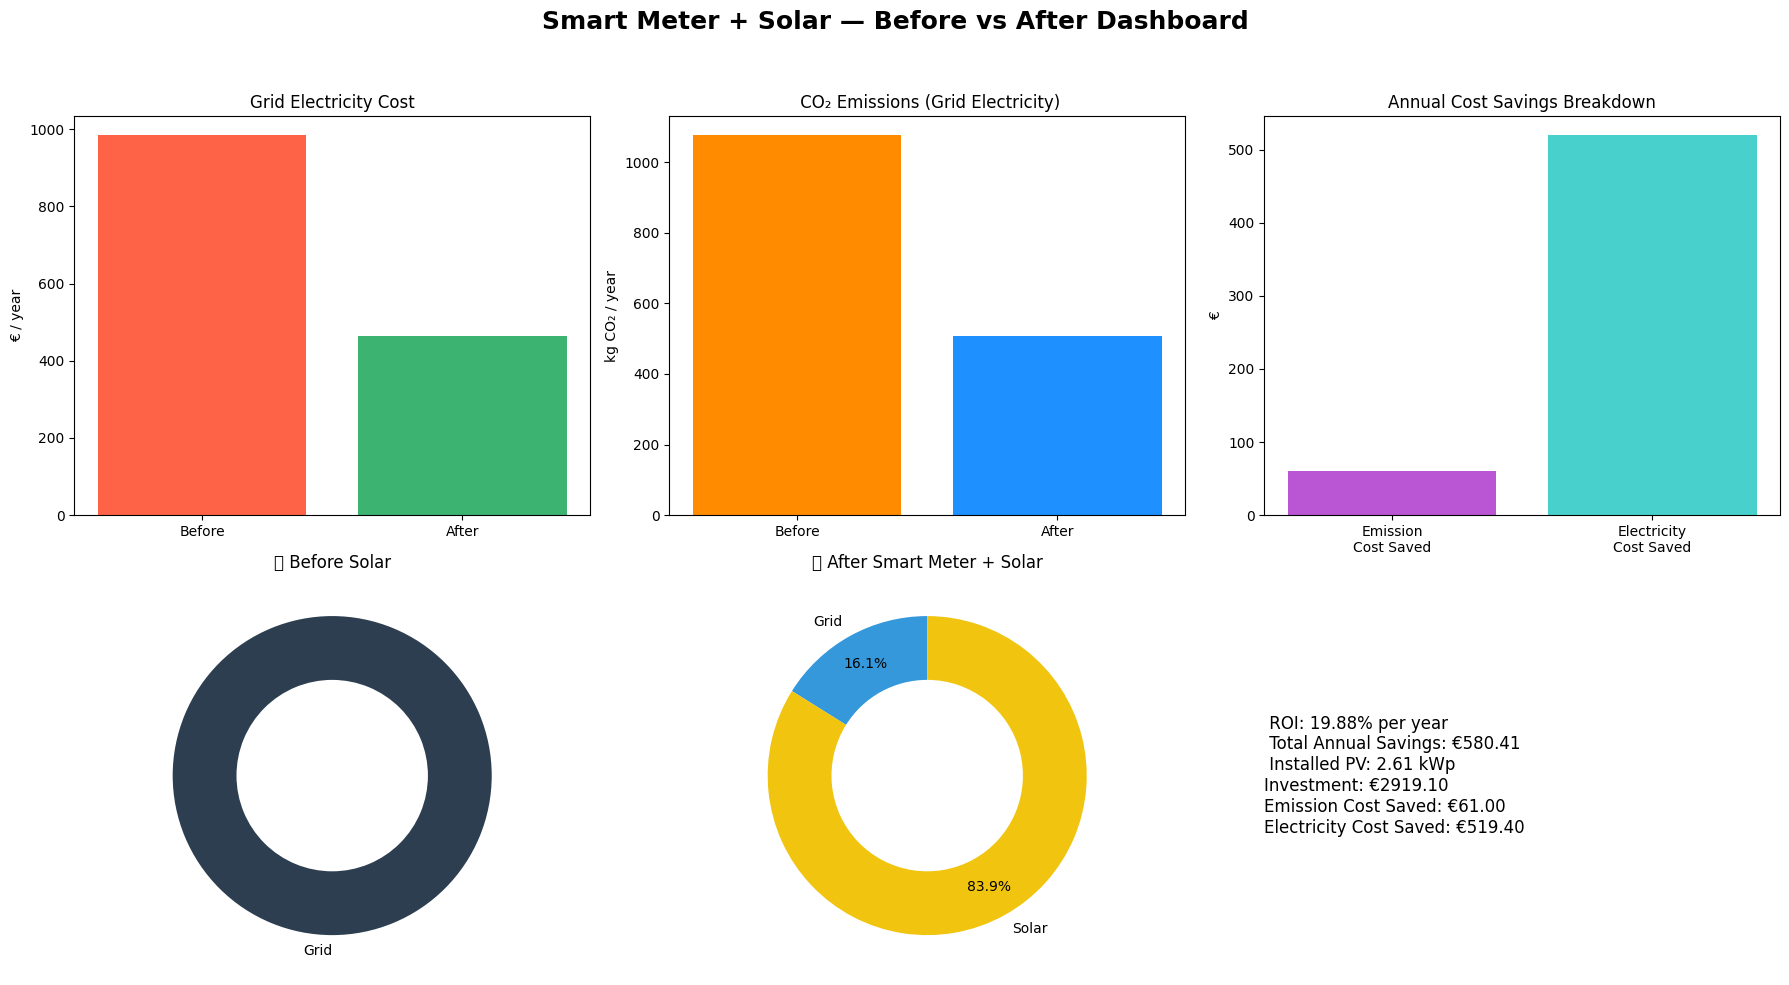

In [14]:


# --- Reduction Assumptions ---
smart_meter_reduction = 0.03  # 3% for both
smart_meter_cost = 50  # €

# --- Reduced Demand (24h Profile) ---
elec_day_smart = avg_day_df['avg_elec_demand_kWh'].values * (1 - smart_meter_reduction)
heat_day_smart = avg_day_df['avg_heat_demand_kWh'].values * (1 - smart_meter_reduction)
time = pd.Index(range(24), name="hour")

# --- Solar Capacity Factor (same)
solar_cf = np.array([
    0.00, 0.00, 0.00, 0.02, 0.05, 0.15, 0.40, 0.65,
    0.85, 0.90, 0.95, 1.00, 0.95, 0.85, 0.60, 0.35,
    0.15, 0.05, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00
])
solar_cf_da = DataArray(solar_cf, coords=[time], dims=["hour"])

# --- PV Optimization
model = linopy.Model()
g = model.add_variables(coords=[time], name="grid_supply", lower=0)
s = model.add_variables(coords=[time], name="solar_supply", lower=0)
C = model.add_variables(name="solar_capacity", lower=0)

model.add_constraints(g + s >= elec_day_smart, name="demand")
model.add_constraints(s <= C.to_linexpr().expand_dims(hour=time) * solar_cf_da, name="cf_limit")

grid_price = 0.32
carbon_price = 0.08
emission_factor = 0.35

grid_cost = g * grid_price
grid_emiss_cost = g * emission_factor * carbon_price
solar_inv = C * 0.1

objective = 0.5 * grid_emiss_cost.sum() + 0.5 * (grid_cost.sum() + solar_inv)
model.add_objective(objective, sense="min")
res = model.solve(solver_name="gurobi")
sol = model.solution

# --- Extract Results
solar_capacity_kWp = sol['solar_capacity'].values
grid_kWh_total = sol['grid_supply'].sum().values * 365
solar_kWh_total = sol['solar_supply'].sum().values * 365
post_heat_demand = heat_day_smart.sum() * 365

# --- Annual Stats
baseline_elec_demand = avg_day_df['avg_elec_demand_kWh'].sum() * 365
baseline_heat_demand = avg_day_df['avg_heat_demand_kWh'].sum() * 365
baseline_emissions = (baseline_elec_demand + baseline_heat_demand) * emission_factor
baseline_energy_cost = baseline_elec_demand * grid_price
baseline_emission_cost = baseline_emissions * carbon_price

post_energy_cost = grid_kWh_total * grid_price
post_emission_cost = (grid_kWh_total + post_heat_demand) * emission_factor * carbon_price
post_emissions = (grid_kWh_total + post_heat_demand) * emission_factor

# --- Savings & ROI
energy_cost_saving = baseline_energy_cost - post_energy_cost
emission_cost_saving = baseline_emission_cost - post_emission_cost
cost_saved = energy_cost_saving + emission_cost_saving
total_investment = solar_capacity_kWp * 1100 + smart_meter_cost
roi_cumulative = (cost_saved / total_investment) * 100

# --- Shares for Donut
total_energy_after = grid_kWh_total + solar_kWh_total + 1e-6
grid_share = grid_kWh_total / total_energy_after
solar_share = solar_kWh_total / total_energy_after

# === DASHBOARD ===
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Smart Meter + Solar — Before vs After Dashboard", fontsize=18, fontweight='bold')

# Grid Electricity Cost
axs[0, 0].bar(['Before', 'After'], [baseline_energy_cost, post_energy_cost], 
              color=['tomato', 'mediumseagreen'])
axs[0, 0].set_title("Grid Electricity Cost")
axs[0, 0].set_ylabel("€ / year")

# CO₂ Emissions (Electricity)
axs[0, 1].bar(['Before', 'After'], 
              [baseline_elec_demand * emission_factor, grid_kWh_total * emission_factor],
              color=['darkorange', 'dodgerblue'])
axs[0, 1].set_title(" CO₂ Emissions (Grid Electricity)")
axs[0, 1].set_ylabel("kg CO₂ / year")

# Cost Saving Breakdown
axs[0, 2].bar(['Emission\nCost Saved', 'Electricity\nCost Saved'], 
              [emission_cost_saving, energy_cost_saving],
              color=['mediumorchid', 'mediumturquoise'])
axs[0, 2].set_title("Annual Cost Savings Breakdown")
axs[0, 2].set_ylabel("€")

# Donut Before
axs[1, 0].pie([1], labels=['Grid'], colors=['#2c3e50'], startangle=90, wedgeprops=dict(width=0.4))
axs[1, 0].text(0, 0, '100.0%', ha='center', va='center', fontsize=12, color='white')
axs[1, 0].set_title("🔌 Before Solar")

# Donut After
axs[1, 1].pie([grid_share, solar_share],
              labels=['Grid', 'Solar'],
              colors=['#3498db', '#f1c40f'],
              startangle=90,
              autopct='%1.1f%%',
              pctdistance=0.8,
              wedgeprops=dict(width=0.4))
axs[1, 1].set_title("📱 After Smart Meter + Solar")

# Text Summary
axs[1, 2].axis('off')
summary_text = (
    f" ROI: {roi_cumulative:.2f}% per year\n"
    f" Total Annual Savings: €{cost_saved:.2f}\n"
    f" Installed PV: {solar_capacity_kWp:.2f} kWp\n"
    f"Investment: €{total_investment:.2f}\n"
    f"Emission Cost Saved: €{emission_cost_saving:.2f}\n"
    f"Electricity Cost Saved: €{energy_cost_saving:.2f}"
)
axs[1, 2].text(0, 0.5, summary_text, fontsize=12, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Behavioral Nudges + Solar PV Dashboard

This Section models and visualizes the impact of behavioral nudges (social comparison) combined with solar PV installation on household energy use. It optimizes energy supply, calculates annual costs, emissions, savings, investment, and ROI, and presents before-and-after results using bar and donut charts. The dashboard highlights financial and environmental improvements from behavioral interventions and solar integration.

Restricted license - for non-production use only - expires 2026-11-23
Read LP format model from file C:\Users\linus\AppData\Local\Temp\linopy-problem-gygq0qnu.lp
Reading time = 0.00 seconds
obj: 48 rows, 49 columns, 88 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26120.2))

CPU model: AMD Ryzen 7 4800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 48 rows, 49 columns and 88 nonzeros
Model fingerprint: 0x0109dede
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [5e-02, 2e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 6e-01]
Presolve removed 42 rows and 42 columns
Presolve time: 0.01s
Presolved: 6 rows, 7 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.3917208e-01   1.102310e+00   0.000000e+00      0s
       4    8.3097408e-01   0.000000e+00   0.0

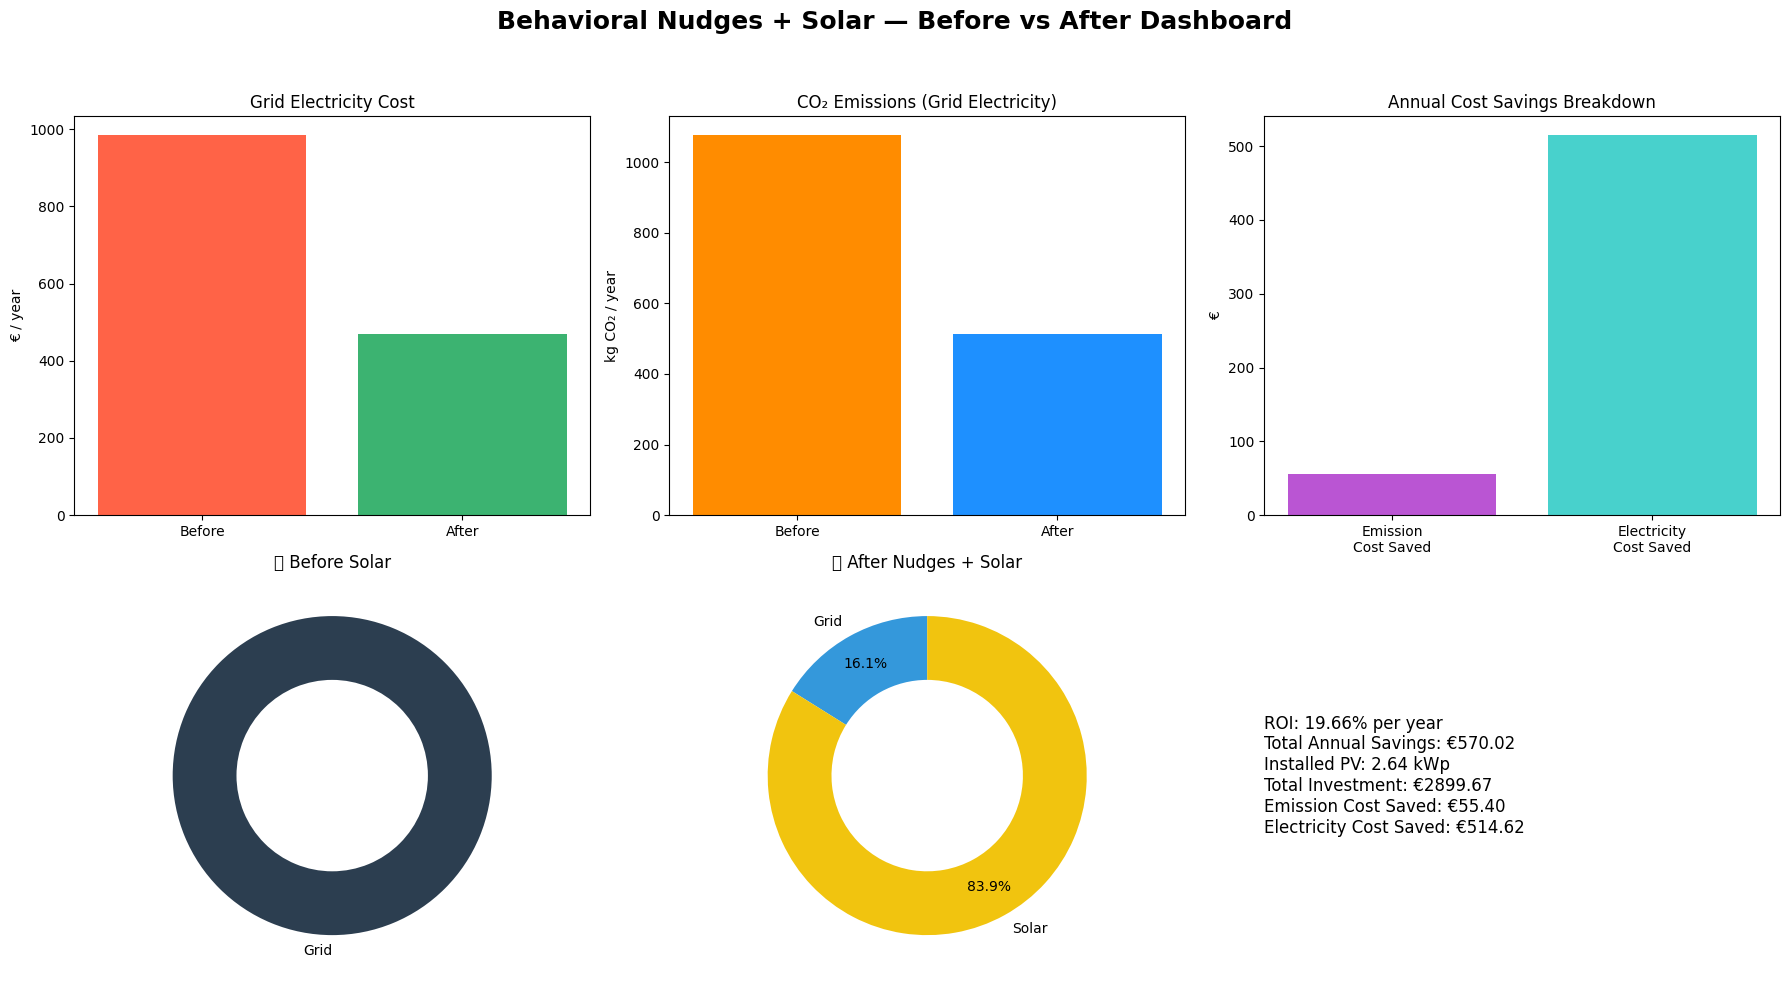

In [15]:

# --- Reduction Assumptions ---
nudge_reduction = 0.02
nudge_cost = 1

# --- Reduced Demand (24h Profile) ---
elec_day_nudge = avg_day_df['avg_elec_demand_kWh'].values * (1 - nudge_reduction)
heat_day_nudge = avg_day_df['avg_heat_demand_kWh'].values * (1 - nudge_reduction)
time = pd.Index(range(24), name="hour")

# --- Solar CF
solar_cf = np.array([
    0.00, 0.00, 0.00, 0.02, 0.05, 0.15, 0.40, 0.65,
    0.85, 0.90, 0.95, 1.00, 0.95, 0.85, 0.60, 0.35,
    0.15, 0.05, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00
])
solar_cf_da = DataArray(solar_cf, coords=[time], dims=["hour"])

# --- PV Optimization
model = linopy.Model()
g = model.add_variables(coords=[time], name="grid_supply", lower=0)
s = model.add_variables(coords=[time], name="solar_supply", lower=0)
C = model.add_variables(name="solar_capacity", lower=0)

model.add_constraints(g + s >= elec_day_nudge, name="demand")
model.add_constraints(s <= C.to_linexpr().expand_dims(hour=time) * solar_cf_da, name="cf_limit")

# Cost factors
grid_price = 0.32
carbon_price = 0.08
emission_factor = 0.35

grid_cost = g * grid_price
grid_emiss_cost = g * emission_factor * carbon_price
solar_inv = C * 0.1

objective = 0.5 * grid_emiss_cost.sum() + 0.5 * (grid_cost.sum() + solar_inv)
model.add_objective(objective, sense="min")
res = model.solve(solver_name="gurobi")
sol = model.solution

# --- Extract Results
solar_capacity_kWp = sol['solar_capacity'].values
grid_kWh_total = sol['grid_supply'].sum().values * 365
solar_kWh_total = sol['solar_supply'].sum().values * 365
post_heat_demand = heat_day_nudge.sum() * 365

# --- Annual Stats
baseline_elec_demand = avg_day_df['avg_elec_demand_kWh'].sum() * 365
baseline_heat_demand = avg_day_df['avg_heat_demand_kWh'].sum() * 365
baseline_emissions = (baseline_elec_demand + baseline_heat_demand) * emission_factor
baseline_energy_cost = baseline_elec_demand * grid_price
baseline_emission_cost = baseline_emissions * carbon_price

post_energy_cost = grid_kWh_total * grid_price
post_emission_cost = (grid_kWh_total + post_heat_demand) * emission_factor * carbon_price
post_emissions = (grid_kWh_total + post_heat_demand) * emission_factor

# --- Savings & ROI
energy_cost_saving = baseline_energy_cost - post_energy_cost
emission_cost_saving = baseline_emission_cost - post_emission_cost
cost_saved = energy_cost_saving + emission_cost_saving
total_investment = solar_capacity_kWp * 1100 + nudge_cost
roi_cumulative = (cost_saved / total_investment) * 100

# --- Donut Shares
total_energy_after = grid_kWh_total + solar_kWh_total + 1e-6
grid_share = grid_kWh_total / total_energy_after
solar_share = solar_kWh_total / total_energy_after

# === DASHBOARD ===
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Behavioral Nudges + Solar — Before vs After Dashboard", fontsize=18, fontweight='bold')

# 1️⃣ Grid Electricity Cost
axs[0, 0].bar(['Before', 'After'], [baseline_energy_cost, post_energy_cost], 
              color=['tomato', 'mediumseagreen'])
axs[0, 0].set_title("Grid Electricity Cost")
axs[0, 0].set_ylabel("€ / year")

# 2️⃣ CO₂ Emissions (Electricity)
axs[0, 1].bar(['Before', 'After'], 
              [baseline_elec_demand * emission_factor, grid_kWh_total * emission_factor],
              color=['darkorange', 'dodgerblue'])
axs[0, 1].set_title("CO₂ Emissions (Grid Electricity)")
axs[0, 1].set_ylabel("kg CO₂ / year")

# 3️⃣ Cost Saving Breakdown
axs[0, 2].bar(['Emission\nCost Saved', 'Electricity\nCost Saved'], 
              [emission_cost_saving, energy_cost_saving],
              color=['mediumorchid', 'mediumturquoise'])
axs[0, 2].set_title("Annual Cost Savings Breakdown")
axs[0, 2].set_ylabel("€")

# 4️⃣ Donut Before
axs[1, 0].pie([1], labels=['Grid'], colors=['#2c3e50'], startangle=90, wedgeprops=dict(width=0.4))
axs[1, 0].text(0, 0, '100.0%', ha='center', va='center', fontsize=12, color='white')
axs[1, 0].set_title("🔌 Before Solar")

# 5️⃣ Donut After
axs[1, 1].pie([grid_share, solar_share],
              labels=['Grid', 'Solar'],
              colors=['#3498db', '#f1c40f'],
              startangle=90,
              autopct='%1.1f%%',
              pctdistance=0.8,
              wedgeprops=dict(width=0.4))
axs[1, 1].set_title("🧠 After Nudges + Solar")

# 6️⃣ Text Summary
axs[1, 2].axis('off')
summary_text = (
    f"ROI: {roi_cumulative:.2f}% per year\n"
    f"Total Annual Savings: €{cost_saved:.2f}\n"
    f"Installed PV: {solar_capacity_kWp:.2f} kWp\n"
    f"Total Investment: €{total_investment:.2f}\n"
    f"Emission Cost Saved: €{emission_cost_saving:.2f}\n"
    f"Electricity Cost Saved: €{energy_cost_saving:.2f}"
)
axs[1, 2].text(0, 0.5, summary_text, fontsize=12, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Scenario : Peer Comparison + Solar PV Optimization

This section models and visualizes the impact of behavioral nudges (social comparison) combined with solar PV installation on household energy use. It optimizes energy supply, calculates annual costs, emissions, savings, investment, and ROI, and presents before-and-after results using bar and donut charts. The dashboard highlights financial and environmental improvements from behavioral interventions and solar integration.

Restricted license - for non-production use only - expires 2026-11-23
Read LP format model from file C:\Users\linus\AppData\Local\Temp\linopy-problem-b2fayxjp.lp
Reading time = 0.00 seconds
obj: 48 rows, 49 columns, 88 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26120.2))

CPU model: AMD Ryzen 7 4800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 48 rows, 49 columns and 88 nonzeros
Model fingerprint: 0x0109dede
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [5e-02, 2e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 6e-01]
Presolve removed 42 rows and 42 columns
Presolve time: 0.01s
Presolved: 6 rows, 7 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.3917208e-01   1.102310e+00   0.000000e+00      0s
       4    8.3097408e-01   0.000000e+00   0.0

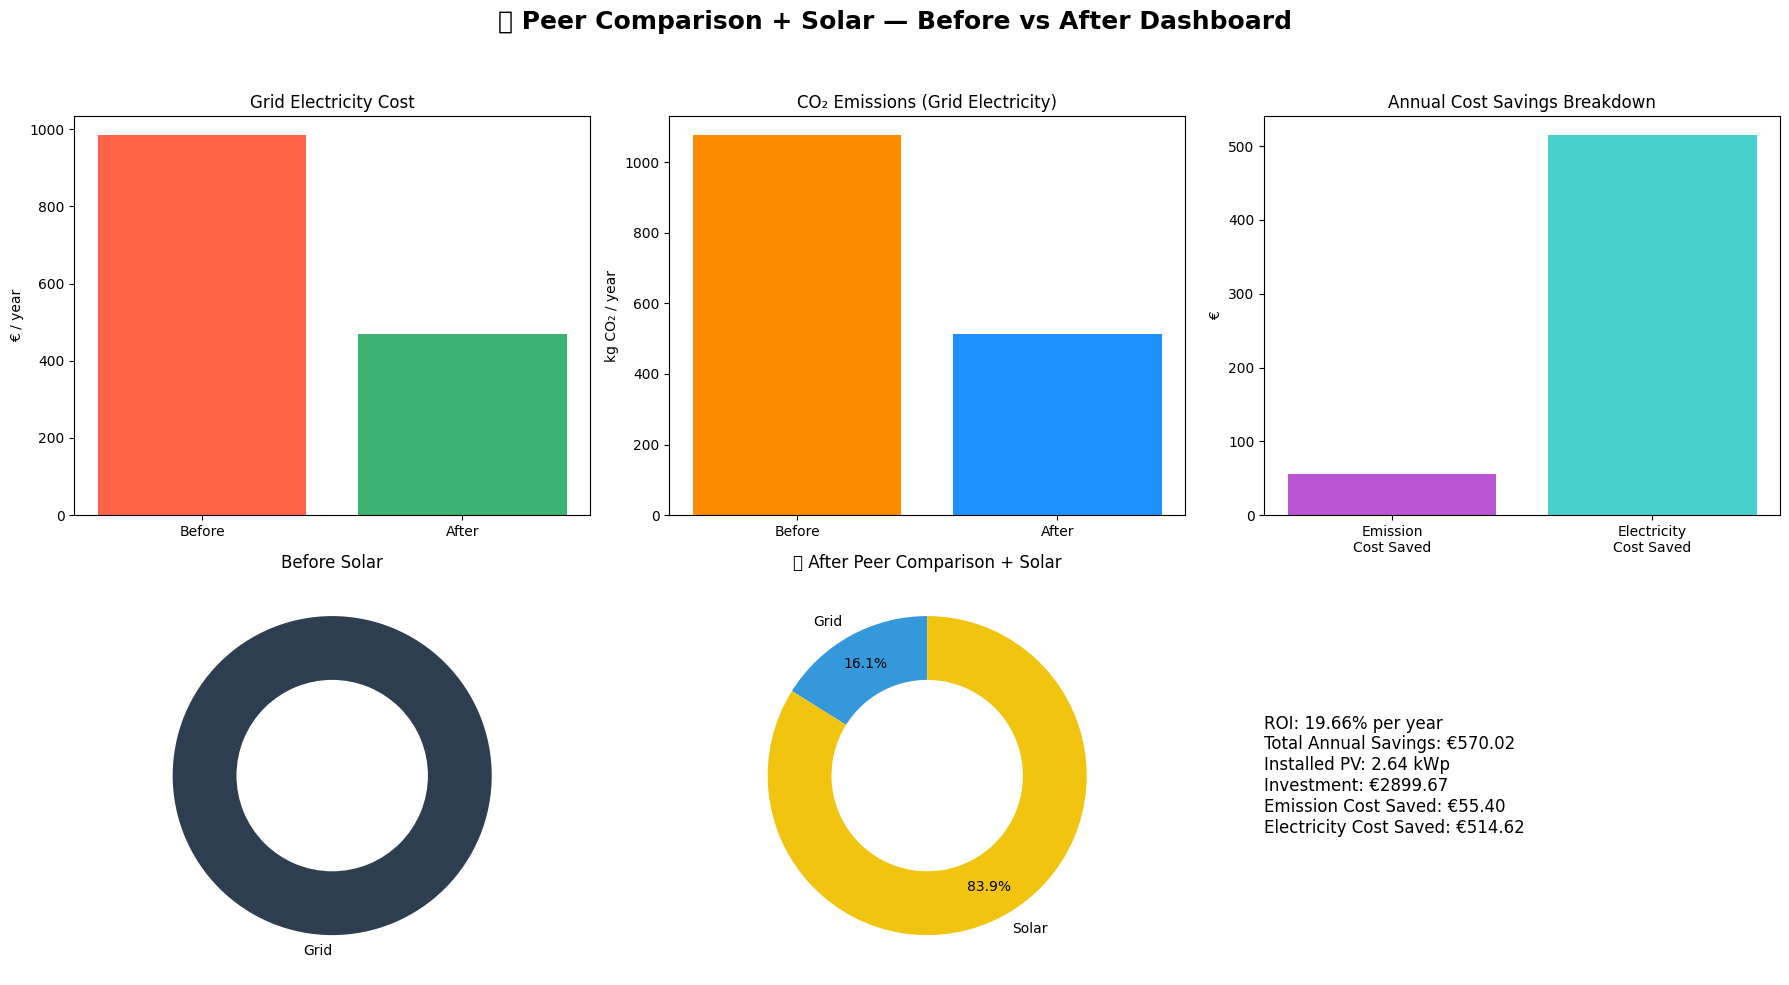

In [16]:
# 1️⃣ Apply Peer Comparison Reduction (2%)
peer_reduction = 0.02
peer_cost = 1

elec_day_peer = avg_day_df['avg_elec_demand_kWh'].values * (1 - peer_reduction)
heat_day_peer = avg_day_df['avg_heat_demand_kWh'].values * (1 - peer_reduction)
time = pd.Index(range(24), name="hour")

# 2️⃣ Set up solar CF
solar_cf = np.array([
    0.00, 0.00, 0.00, 0.02, 0.05, 0.15, 0.40, 0.65,
    0.85, 0.90, 0.95, 1.00, 0.95, 0.85, 0.60, 0.35,
    0.15, 0.05, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00
])
solar_cf_da = DataArray(solar_cf, coords=[time], dims=["hour"])

# 3️⃣ Linopy Optimization
model = linopy.Model()
g = model.add_variables(coords=[time], name="grid_supply", lower=0)
s = model.add_variables(coords=[time], name="solar_supply", lower=0)
C = model.add_variables(name="solar_capacity", lower=0)

model.add_constraints(g + s >= elec_day_peer, name="demand")
model.add_constraints(s <= C.to_linexpr().expand_dims(hour=time) * solar_cf_da, name="cf_limit")

grid_price = 0.32
carbon_price = 0.08
emission_factor = 0.35

grid_cost = g * grid_price
grid_emiss_cost = g * emission_factor * carbon_price
solar_inv = C * 0.1
objective = 0.5 * grid_emiss_cost.sum() + 0.5 * (grid_cost.sum() + solar_inv)
model.add_objective(objective, sense="min")

res = model.solve(solver_name="gurobi")
sol = model.solution

# 4️⃣ Results
solar_capacity_kWp = sol['solar_capacity'].values
grid_kWh_total = sol['grid_supply'].sum().values * 365
solar_kWh_total = sol['solar_supply'].sum().values * 365
post_heat_demand = heat_day_peer.sum() * 365

# 5️⃣ Annual Totals
baseline_elec_demand = avg_day_df['avg_elec_demand_kWh'].sum() * 365
baseline_heat_demand = avg_day_df['avg_heat_demand_kWh'].sum() * 365
baseline_emissions = (baseline_elec_demand + baseline_heat_demand) * emission_factor
baseline_energy_cost = baseline_elec_demand * grid_price
baseline_emission_cost = baseline_emissions * carbon_price

post_energy_cost = grid_kWh_total * grid_price
post_emission_cost = (grid_kWh_total + post_heat_demand) * emission_factor * carbon_price
post_emissions = (grid_kWh_total + post_heat_demand) * emission_factor

# 6️⃣ Savings & ROI
energy_cost_saving = baseline_energy_cost - post_energy_cost
emission_cost_saving = baseline_emission_cost - post_emission_cost
cost_saved = energy_cost_saving + emission_cost_saving
total_investment = solar_capacity_kWp * 1100 + peer_cost
roi_cumulative = (cost_saved / total_investment) * 100

# 7️⃣ Donut Shares
total_energy_after = grid_kWh_total + solar_kWh_total + 1e-6
grid_share = grid_kWh_total / total_energy_after
solar_share = solar_kWh_total / total_energy_after

# === Dashboard ===
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("👥 Peer Comparison + Solar — Before vs After Dashboard", fontsize=18, fontweight='bold')

# 1️⃣ Grid Electricity Cost
axs[0, 0].bar(['Before', 'After'], [baseline_energy_cost, post_energy_cost], 
              color=['tomato', 'mediumseagreen'])
axs[0, 0].set_title("Grid Electricity Cost")
axs[0, 0].set_ylabel("€ / year")

# 2️⃣ CO₂ Emissions (Electricity)
axs[0, 1].bar(['Before', 'After'], 
              [baseline_elec_demand * emission_factor, grid_kWh_total * emission_factor],
              color=['darkorange', 'dodgerblue'])
axs[0, 1].set_title("CO₂ Emissions (Grid Electricity)")
axs[0, 1].set_ylabel("kg CO₂ / year")

# 3️⃣ Cost Saving Breakdown
axs[0, 2].bar(['Emission\nCost Saved', 'Electricity\nCost Saved'], 
              [emission_cost_saving, energy_cost_saving],
              color=['mediumorchid', 'mediumturquoise'])
axs[0, 2].set_title("Annual Cost Savings Breakdown")
axs[0, 2].set_ylabel("€")

# 4️⃣ Donut Before
axs[1, 0].pie([1], labels=['Grid'], colors=['#2c3e50'], startangle=90, wedgeprops=dict(width=0.4))
axs[1, 0].text(0, 0, '100.0%', ha='center', va='center', fontsize=12, color='white')
axs[1, 0].set_title("Before Solar")

# 5️⃣ Donut After
axs[1, 1].pie([grid_share, solar_share],
              labels=['Grid', 'Solar'],
              colors=['#3498db', '#f1c40f'],
              startangle=90,
              autopct='%1.1f%%',
              pctdistance=0.8,
              wedgeprops=dict(width=0.4))
axs[1, 1].set_title("👥 After Peer Comparison + Solar")

# 6️⃣ Summary Text
axs[1, 2].axis('off')
summary_text = (
    f"ROI: {roi_cumulative:.2f}% per year\n"
    f"Total Annual Savings: €{cost_saved:.2f}\n"
    f"Installed PV: {solar_capacity_kWp:.2f} kWp\n"
    f"Investment: €{total_investment:.2f}\n"
    f"Emission Cost Saved: €{emission_cost_saving:.2f}\n"
    f"Electricity Cost Saved: €{energy_cost_saving:.2f}"
)
axs[1, 2].text(0, 0.5, summary_text, fontsize=12, va='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Scenario Comparison Dashboard


This code compares four energy optimization scenarios—PV Only, Smart Meter + PV, Smart Home + PV, and Behavioral Nudges + PV—using bar charts for ROI, annual savings, investment cost, and CO₂ emissions avoided. The dashboard provides a clear visual summary of financial and environmental performance across all interventions.

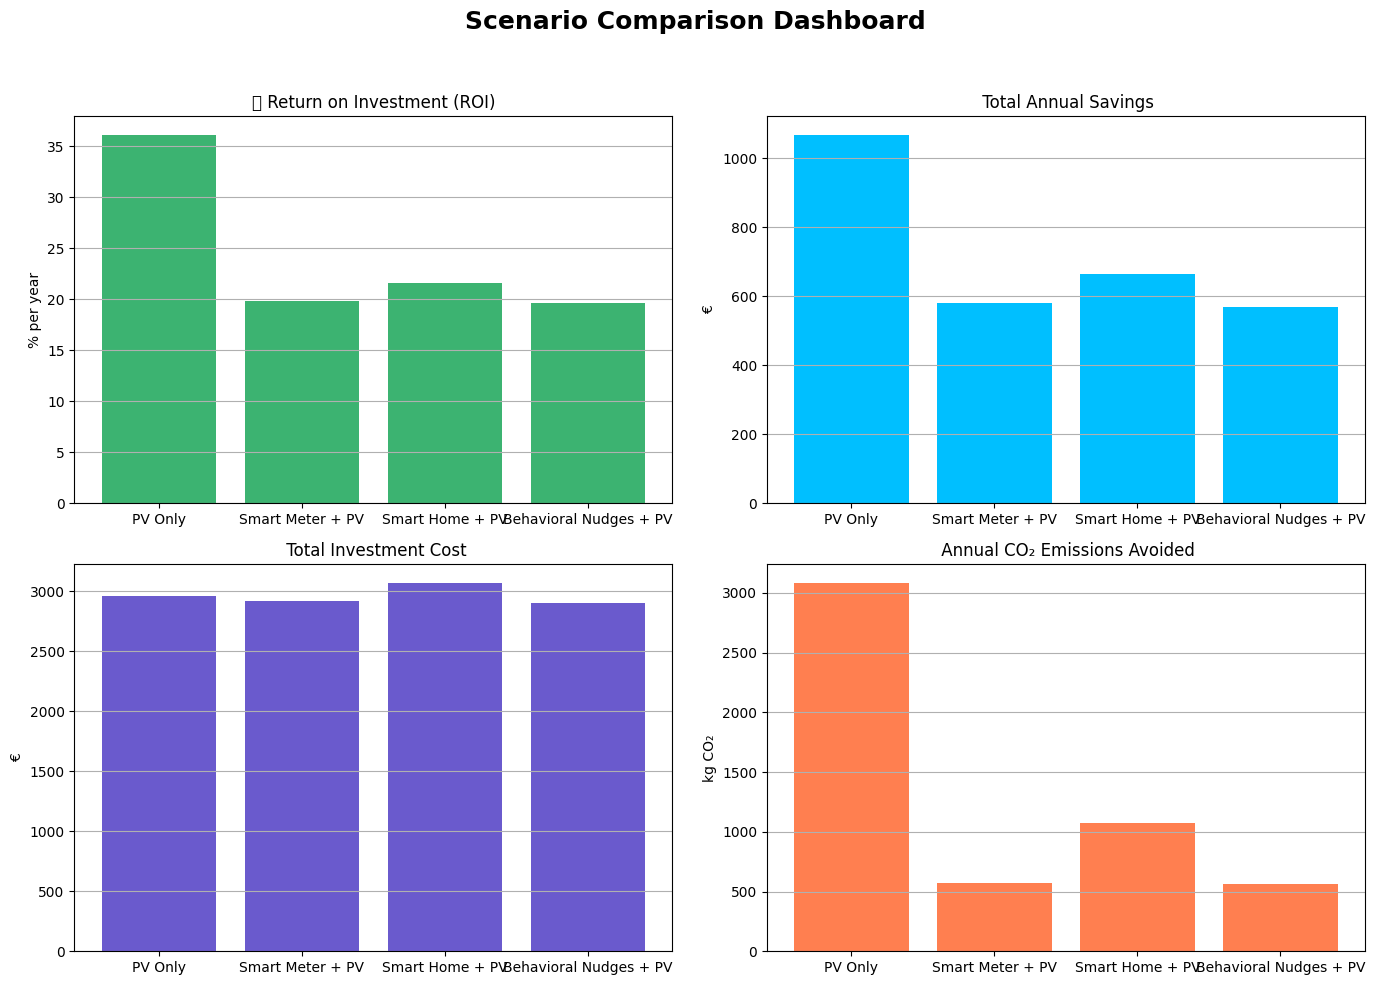

In [17]:

# Data for comparison
scenarios = ['PV Only', 'Smart Meter + PV', 'Smart Home + PV', 'Behavioral Nudges + PV']
installed_pv = [2.69, 2.61, 2.47, 2.64]
roi = [36.13, 19.88, 21.60, 19.66]
annual_savings = [1068.64, 580.41, 663.49, 570.02]
investment = [2957.83, 2919.10, 3071.20, 2899.67]
emission_saved = [3084.71, 519.40 / 0.32 * 0.35, 982.66 / 0.32 * 0.35, 514.62 / 0.32 * 0.35]  # inferred from electricity savings

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Scenario Comparison Dashboard", fontsize=18, fontweight='bold')

# ROI Plot
axs[0, 0].bar(scenarios, roi, color='mediumseagreen')
axs[0, 0].set_title("📈 Return on Investment (ROI)")
axs[0, 0].set_ylabel("% per year")
axs[0, 0].grid(True, axis='y')

# Annual Savings Plot
axs[0, 1].bar(scenarios, annual_savings, color='deepskyblue')
axs[0, 1].set_title(" Total Annual Savings")
axs[0, 1].set_ylabel("€")
axs[0, 1].grid(True, axis='y')

# Investment Plot
axs[1, 0].bar(scenarios, investment, color='slateblue')
axs[1, 0].set_title(" Total Investment Cost")
axs[1, 0].set_ylabel("€")
axs[1, 0].grid(True, axis='y')

# Emission Saved Plot
axs[1, 1].bar(scenarios, emission_saved, color='coral')
axs[1, 1].set_title(" Annual CO₂ Emissions Avoided")
axs[1, 1].set_ylabel("kg CO₂")
axs[1, 1].grid(True, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
